In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [11]:
df = pd.read_csv('student_dropout_behavior_dataset.csv')

In [12]:
df.head()

,student_id,name,age,gender,quiz1_marks,quiz2_marks,quiz3_marks,total_assignments,assignments_submitted,midterm_marks,final_marks,previous_gpa,total_lectures,lectures_attended,total_lab_sessions,labs_attended
0,1,Kristina Vaughan,19,Male,8.0,5.7,7.4,5,NaN,30.0,36.5,2.57,12,4,6,1
1,2,Rodney Daniels,21,Male,10.0,7.9,4.1,5,NaN,25.4,33.0,2.40,12,1,6,5
2,3,Jose Nash,19,Female,7.5,1.2,0.3,5,NaN,14.4,24.8,2.99,12,0,6,0
3,4,Nicole Martin,21,Male,5.2,2.5,9.9,5,NaN,17.7,41.0,1.68,12,9,6,0
4,5,Shelby Smith,21,Female,5.9,6.3,2.0,5,NaN,23.8,31.0,2.53,12,7,6,4


In [13]:
df.shape

(300, 16)

In [20]:
df = df.drop(['student_id','name','quiz1_marks','quiz2_marks','quiz3_marks','total_assignments','assignments_submitted','midterm_marks','total_lab_sessions','labs_attended'],axis=1)

In [24]:
from sklearn.preprocessing import OneHotEncoder

encoder = OneHotEncoder(sparse_output=False)
df['gender'] = encoder.fit_transform(df[['gender']])

In [26]:
df['gender'] = df['gender'].astype(int)

In [27]:
df

,age,gender,final_marks,previous_gpa,total_lectures,lectures_attended
0,19,0,36.5,2.57,12,4
1,21,0,33.0,2.40,12,1
2,19,1,24.8,2.99,12,0
3,21,0,41.0,1.68,12,9
4,21,1,31.0,2.53,12,7
...,...,...,...,...,...,...
295,18,0,28.9,1.76,12,8
296,24,1,18.9,2.69,12,5
297,23,1,35.4,2.19,12,5
298,19,0,37.6,3.25,12,2


In [28]:
from sklearn.cluster import KMeans

In [29]:
wcss = []

for k in range(1,10):

    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(df)

    wcss.append(kmeans.inertia_)

D:\my\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
D:\my\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
D:\my\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
D:\my\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid

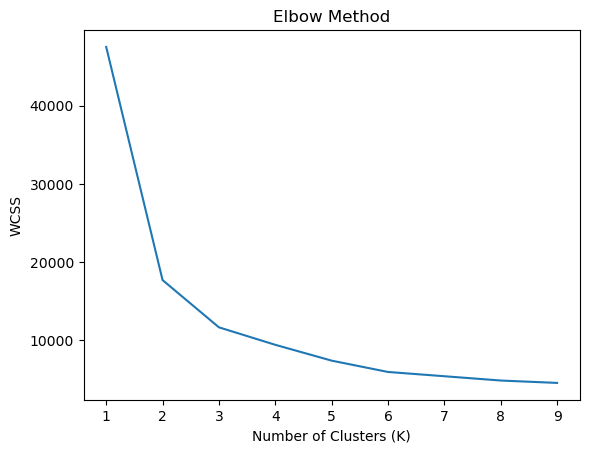

In [30]:
plt.plot(range(1,10), wcss)
plt.xlabel("Number of Clusters (K)")
plt.ylabel("WCSS")
plt.title("Elbow Method")
plt.show()

In [31]:
kmeans = KMeans(n_clusters=3, random_state=42)

kmeans.fit(df)

D:\my\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


KMeans(n_clusters=3, random_state=42)

In [32]:
kmeans.labels_

array([2, 2, 0, 2, 2, 1, 1, 2, 2, 1, 1, 1, 2, 1, 2, 2, 0, 1, 2, 1, 1, 0,
       2, 0, 1, 1, 0, 1, 2, 2, 2, 2, 0, 1, 1, 2, 1, 2, 2, 2, 0, 0, 1, 0,
       2, 0, 1, 2, 2, 1, 2, 2, 1, 2, 1, 1, 2, 0, 1, 1, 1, 2, 1, 0, 1, 1,
       0, 0, 0, 1, 1, 0, 1, 0, 2, 2, 1, 1, 0, 1, 2, 2, 0, 0, 2, 2, 0, 0,
       2, 1, 0, 2, 2, 1, 0, 1, 1, 2, 1, 2, 1, 1, 2, 1, 2, 0, 2, 0, 2, 1,
       2, 1, 0, 2, 1, 1, 2, 0, 2, 2, 1, 1, 1, 2, 2, 0, 2, 2, 1, 2, 1, 1,
       2, 2, 1, 1, 2, 1, 0, 1, 1, 2, 2, 1, 1, 2, 1, 1, 1, 1, 1, 2, 1, 1,
       1, 1, 0, 0, 0, 1, 2, 1, 2, 0, 2, 0, 1, 1, 1, 2, 1, 2, 0, 1, 1, 2,
       1, 0, 2, 1, 1, 2, 2, 1, 2, 1, 1, 1, 1, 1, 2, 0, 2, 0, 1, 2, 1, 0,
       2, 1, 2, 0, 2, 1, 1, 2, 2, 2, 0, 2, 1, 1, 1, 1, 0, 2, 2, 2, 1, 2,
       2, 1, 2, 1, 0, 2, 2, 2, 0, 2, 1, 1, 0, 1, 2, 2, 1, 1, 1, 1, 1, 1,
       1, 2, 0, 2, 1, 0, 2, 1, 2, 0, 1, 2, 2, 2, 2, 0, 2, 1, 1, 1, 0, 0,
       2, 0, 2, 1, 1, 2, 1, 1, 0, 2, 1, 1, 1, 0, 2, 1, 0, 1, 0, 1, 2, 2,
       1, 2, 2, 1, 0, 0, 2, 2, 1, 2, 0, 2, 2, 1], d

In [33]:
df["Cluster"] = kmeans.labels_

In [34]:
df

,age,gender,final_marks,previous_gpa,total_lectures,lectures_attended,Cluster
0,19,0,36.5,2.57,12,4,2
1,21,0,33.0,2.40,12,1,2
2,19,1,24.8,2.99,12,0,0
3,21,0,41.0,1.68,12,9,2
4,21,1,31.0,2.53,12,7,2
...,...,...,...,...,...,...,...
295,18,0,28.9,1.76,12,8,2
296,24,1,18.9,2.69,12,5,0
297,23,1,35.4,2.19,12,5,2
298,19,0,37.6,3.25,12,2,2


In [35]:
df.to_csv('clustered.csv')

### Observation!
Final Marks Range:

Cluster 0 : 0-30 range

Cluster 1 : Typically 45-50

Cluster 2 : 30-45 range

#### Attendance Pattern:
Cluster 2 has the highest attendance but only average marks, indicating that attendance alone doesn't guarantee top performance.

#### Attendance vs Performance:
Surprisingly, Cluster 1 (highest marks) doesn't have the highest attendance.